In [10]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

from dekef.base_density import *

import seaborn as sns
from IPython.display import Markdown as md

from matplotlib import ticker, cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse

from dekef.scorematching_common_functions import sq_rkhs_norm_matrix
from dekef.kernel_function import *

In [3]:
os.chdir('../')

df = np.load('data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]
contam_data = 108.

In [4]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [5]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [6]:
bw = 5.0
kernel_type = 'gaussian_poly2'
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenGamma(waiting, 36., 2.)

### comparison of penalized and early stopping SM density estimates 

In [7]:
pen_folder = (f'data/data=geyser-waiting-PenSM-bw={bw}-kernel={kernel_type}-' + 
              f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
              f'entire-RKHS')

es_folder = (f'data/data=geyser-waiting-EarlyStoppingSM-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'entire-RKHS')

In [9]:
#pen_list = [-15., -12.5, -12., -11., -9., -8., -6., -3.][::-1]
pen_list = [-12., -11., -10., -9.5, -7.5, -6., -5., -2.][::-1]

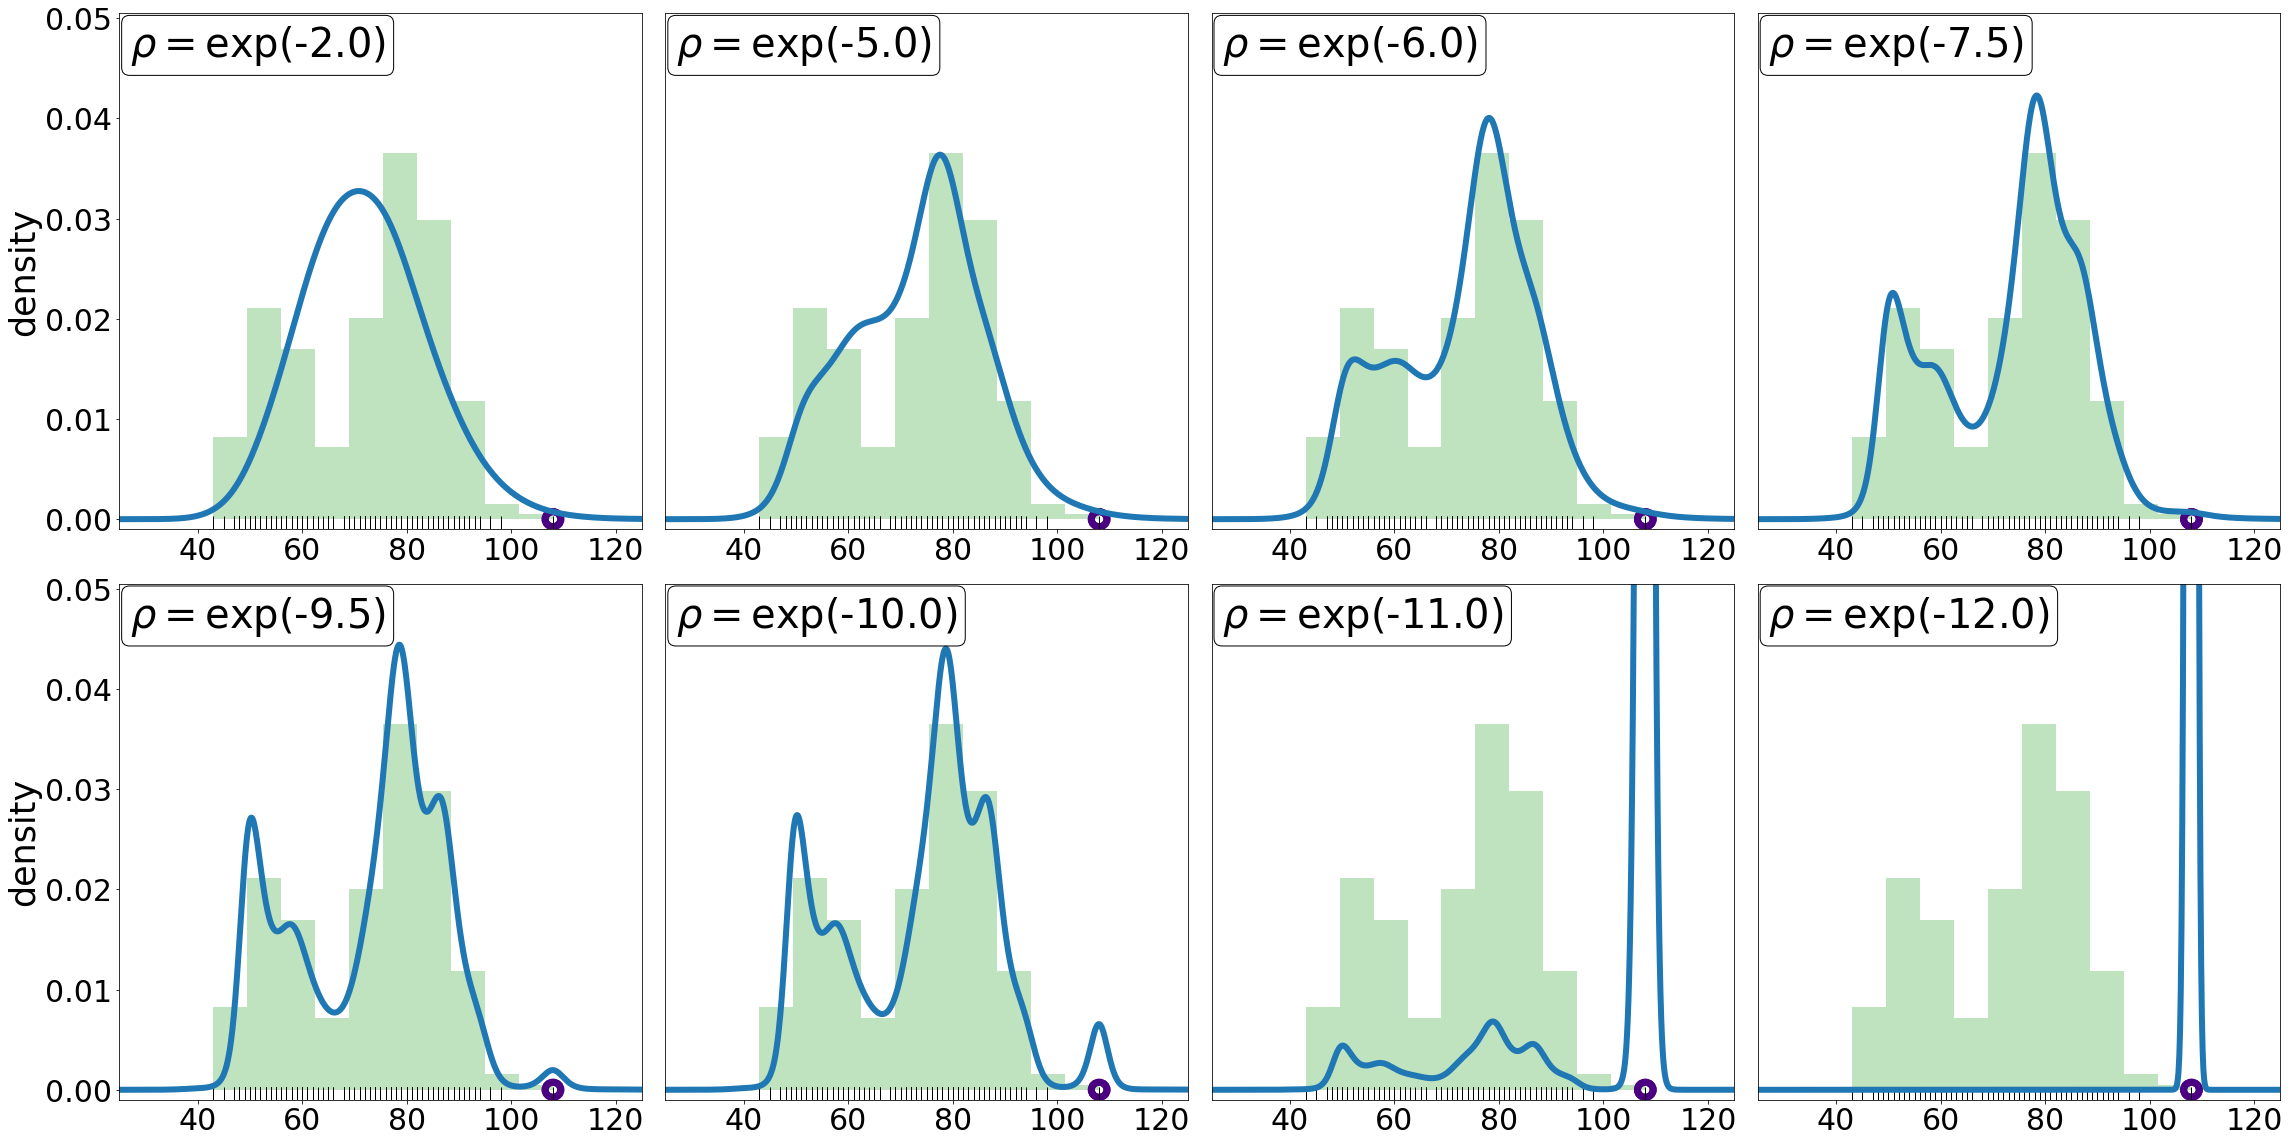

In [23]:
# penalized only 
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 4

fig = plt.figure(figsize=(32, 16))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(pen_folder + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(ncols): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(pen_folder + f'/logpenparam={pen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
    
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
        
    info = r"$\rho=$exp({ll})".format(ll = pen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
for i in range(ncols): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(pen_folder + f'/logpenparam={pen_list[i+ncols]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
        
    info = r"$\rho=$exp({ll})".format(ll = pen_list[i+ncols])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-density-estimates-penalized-only-bw={bw}-baseden=Gamma-{base_density.a}-{base_density.scale}-entireRKHS.pdf', 
            bbox_inches = 'tight')
plt.show()


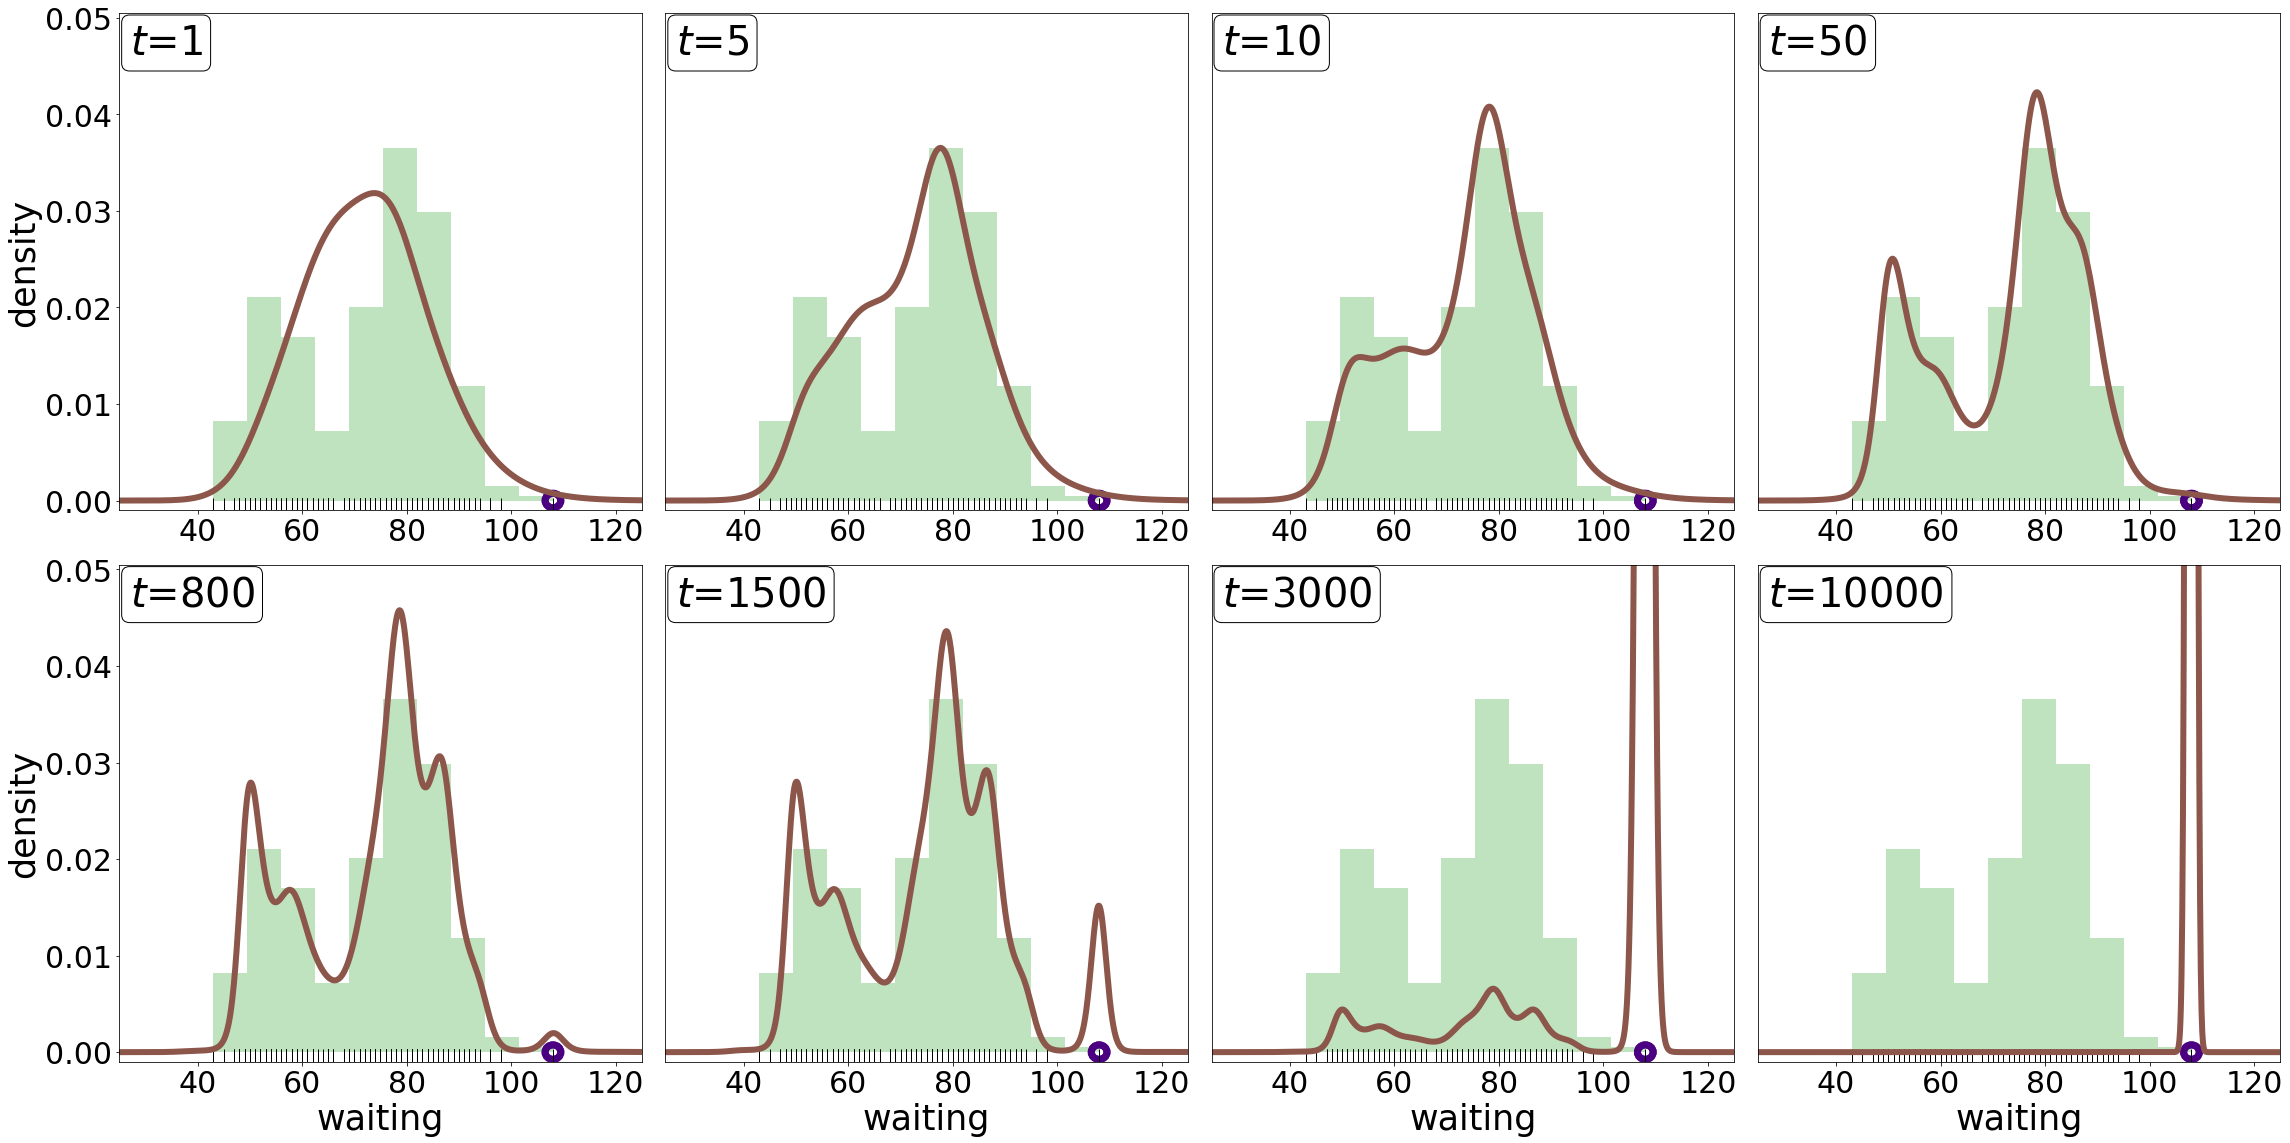

In [22]:
# early stopping only 
iter_list = [10000, 3000, 1500, 800, 50, 10, 5, 1][::-1] # bw = 5.0 

den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 4

fig = plt.figure(figsize=(32, 16))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(pen_folder + f'/new_data.npy')

for i in range(ncols): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(es_folder + f'/iter_num={iter_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
    
    # ax1.axvline(108.)
    
    info = r"$t$={ll}".format(ll = iter_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(ncols): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(es_folder + f'/iter_num={iter_list[i+ncols]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
    
    # ax1.axvline(108.)
    
    info = r"$t$={ll}".format(ll = iter_list[i+ncols])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-density-estimates-earlystopping-only-bw={bw}-baseden=Gamma-{base_density.a}-{base_density.scale}-entireRKHS.pdf', 
            bbox_inches = 'tight')
plt.show()

In [29]:
iter_list = [8000, 3000, 1000, 500, 50, 10, 5, 1][::-1] # bw = 5.0 
pen_list = [-12., -11., -10., -9.5, -7.5, -6., -5., -3.][::-1]

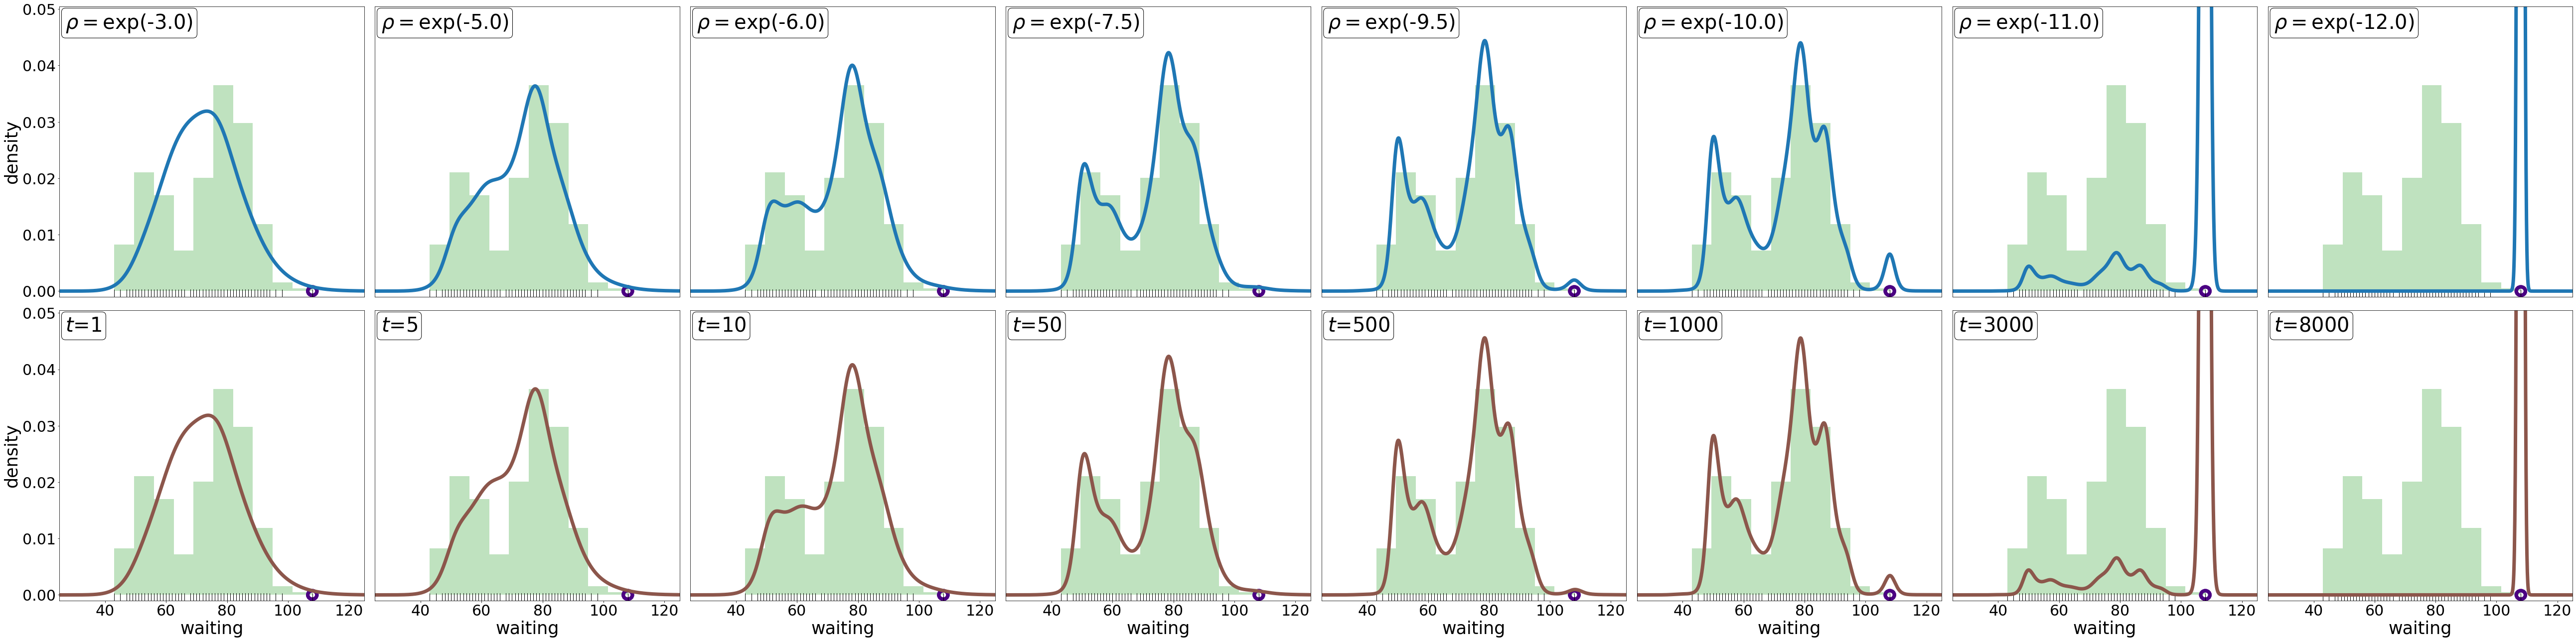

In [30]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 7.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 8

fig = plt.figure(figsize=(72, 18))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(pen_folder + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(len(pen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(pen_folder + f'/logpenparam={pen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = pen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(len(iter_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(es_folder + f'/iter_num={iter_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
    
    # ax1.axvline(108.)
    
    info = r"$t$={ll}".format(ll = iter_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-density-estimates-pen-vs-earlystopping-baseden=Gamma-{base_density.a}-{base_density.scale}-entireRKHS-2.pdf', 
            bbox_inches = 'tight')
plt.show()


In [18]:
kernel_function = GaussianPoly2(data = waiting, r1 = 1., r2 = 0., c = 0., bw = 5.)
gram = sq_rkhs_norm_matrix(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density)

import pandas as pd

In [28]:
iter_list = [8000, 3000, 1000, 500, 50, 10, 5, 1][::-1] # bw = 5.0 
pen_list = [-12., -11., -10., -9.5, -7.5, -6., -5., -3.][::-1]

norm1 = []
norm2 = []

for i in range(len(pen_list)): 
    
    contam_coef = np.load(pen_folder + f'/logpenparam={pen_list[i]}-coef.npy').reshape(-1, 1)
    norm = contam_coef.T @ gram @ contam_coef
    norm1.append(np.sqrt(norm).item())

for i in range(len(iter_list)): 
    
    contam_coef = np.load(es_folder + f'/iter_num={iter_list[i]}-coef.npy').reshape(-1, 1)
    norm = contam_coef.T @ gram @ contam_coef
    norm2.append(np.sqrt(norm).item())

pd.DataFrame({'pen_val': pen_list, 'pen_norm': norm1, 'es_val': iter_list, 'es_norm': norm2})

,pen_val,pen_norm,es_val,es_norm
0,-3.0,0.175742,1,0.190365
1,-5.0,0.891391,5,0.801143
2,-6.0,1.582355,10,1.334681
3,-7.5,3.051414,50,2.869154
4,-9.5,7.849055,500,7.767276
5,-10.0,10.304496,1000,11.279518
6,-11.0,18.833612,3000,21.094397
7,-12.0,39.779532,8000,41.321625


In [9]:
pen_list = [-12., -11., -10., -7.5, -6., -2.][::-1]
iter_list = [10000, 3000, 1500, 50, 10, 1][::-1] # bw = 5.0 

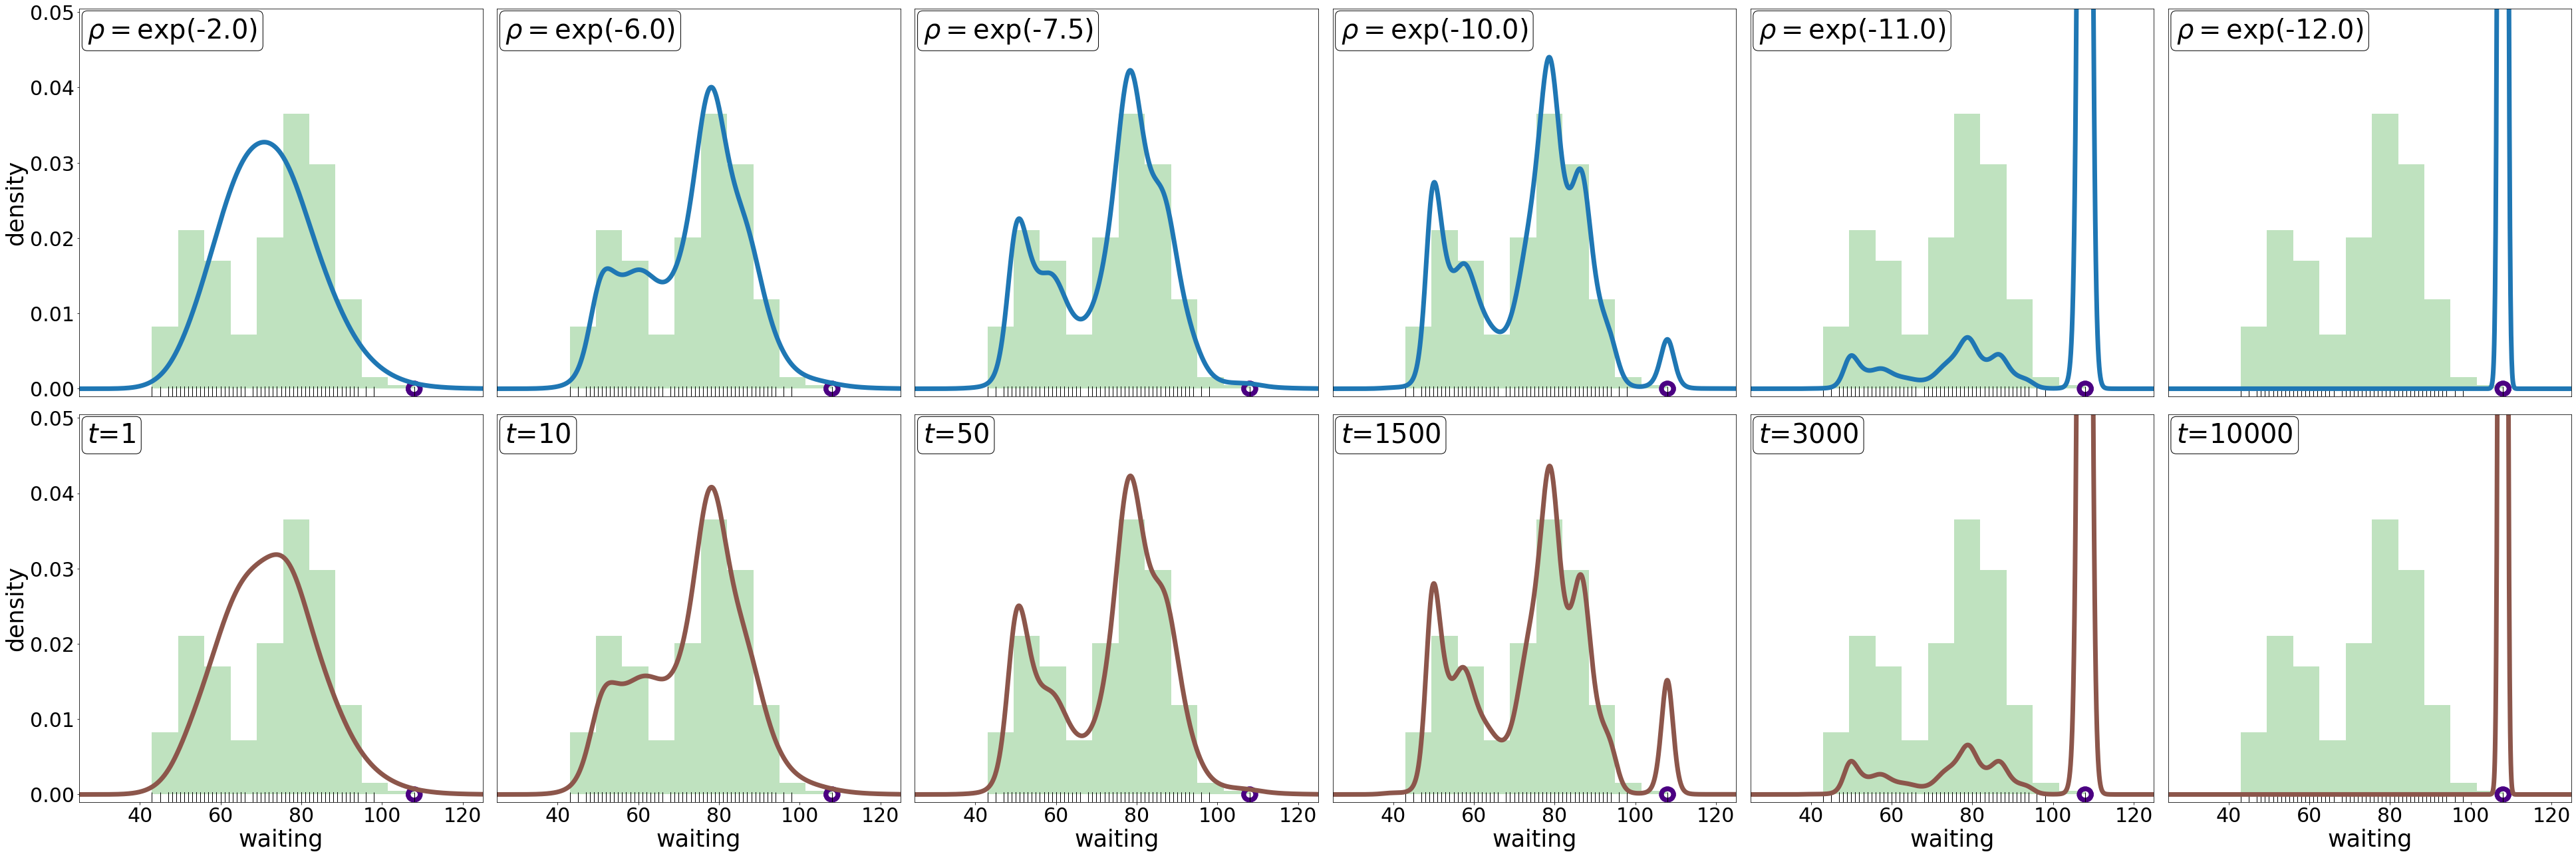

In [12]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 7.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 6

fig = plt.figure(figsize=(54, 18))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(pen_folder + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(len(pen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(pen_folder + f'/logpenparam={pen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = pen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(len(iter_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(es_folder + f'/iter_num={iter_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')

    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
    
    # ax1.axvline(108.)
    
    info = r"$t$={ll}".format(ll = iter_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-density-estimates-pen-vs-earlystopping-baseden=Gamma-{base_density.a}-{base_density.scale}-entireRKHS-presentation.pdf', 
            bbox_inches = 'tight')
plt.show()
